## Import

In [9]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

## CPU and GPU Env

In [10]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

## 전처리 된 데이터 불러오기

In [11]:
DATA_PATH = "../data/processed_data/full_processed.csv"
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print(df.columns.tolist())
display(df.head())

shape: (2018352, 31)
['row_id', 'prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'target', 'datetime', 'date', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'data_block_id', 'eic_count', 'installed_capacity', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'lag_1', 'lag_24']


,row_id,prediction_unit_id,county,is_business,product_type,is_consumption,target,datetime,date,hour,...,snowfall,surface_pressure,cloudcover_total,windspeed_10m,shortwave_radiation,euros_per_mwh,lowest_price_per_mwh,highest_price_per_mwh,lag_1,lag_24
0,0,0,0,0,1,0,0.713,2021-09-01 00:00:00,2021-09-01,0,...,0.0,1009.517857,48.294643,5.114335,6.312500,92.51,45.23,46.32,0.713,0.713
1,122,0,0,0,1,0,1.132,2021-09-01 01:00:00,2021-09-01,1,...,0.0,1009.345536,42.803571,5.082341,3.892857,88.90,45.23,46.32,0.713,0.713
2,244,0,0,0,1,0,0.490,2021-09-01 02:00:00,2021-09-01,2,...,0.0,1008.944643,35.312500,5.035466,1.758929,87.35,45.23,46.32,1.132,0.713
3,366,0,0,0,1,0,0.496,2021-09-01 03:00:00,2021-09-01,3,...,0.0,1008.779464,33.491071,5.165675,0.330357,86.88,45.23,46.32,0.490,0.713
4,488,0,0,0,1,0,0.149,2021-09-01 04:00:00,2021-09-01,4,...,0.0,1008.670536,29.973214,5.284226,0.000000,88.43,45.23,46.32,0.496,0.713


# Baseline (Linear Regression)

### Data 확인

In [12]:
## datetime 처리
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

## 결측 확인
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(15))
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

row_id                0
prediction_unit_id    0
county                0
is_business           0
product_type          0
is_consumption        0
target                0
datetime              0
date                  0
hour                  0
weekday               0
month                 0
day                   0
dayofyear             0
weekofyear            0
dtype: int64


## 데이터 전처리

In [13]:
drop_cols = ["target", "datetime", "date", "row_id"]  
X = df.drop(columns=drop_cols)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

split_date = df["datetime"].quantile(0.8)

X_train = X[df["datetime"] < split_date]
y_train = y[df["datetime"] < split_date]

X_valid = X[df["datetime"] >= split_date]
y_valid = y[df["datetime"] >= split_date]

print("split_date:", split_date)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X shape: (2018352, 27)
y shape: (2018352,)


,prediction_unit_id,county,is_business,product_type,is_consumption,hour,weekday,month,day,dayofyear,...,snowfall,surface_pressure,cloudcover_total,windspeed_10m,shortwave_radiation,euros_per_mwh,lowest_price_per_mwh,highest_price_per_mwh,lag_1,lag_24
0,0,0,0,1,0,0,2,9,1,244,...,0.0,1009.517857,48.294643,5.114335,6.312500,92.51,45.23,46.32,0.713,0.713
1,0,0,0,1,0,1,2,9,1,244,...,0.0,1009.345536,42.803571,5.082341,3.892857,88.90,45.23,46.32,0.713,0.713
2,0,0,0,1,0,2,2,9,1,244,...,0.0,1008.944643,35.312500,5.035466,1.758929,87.35,45.23,46.32,1.132,0.713
3,0,0,0,1,0,3,2,9,1,244,...,0.0,1008.779464,33.491071,5.165675,0.330357,86.88,45.23,46.32,0.490,0.713
4,0,0,0,1,0,4,2,9,1,244,...,0.0,1008.670536,29.973214,5.284226,0.000000,88.43,45.23,46.32,0.496,0.713


0    0.713
1    1.132
2    0.490
3    0.496
4    0.149
Name: target, dtype: float64

split_date: 2023-01-25 01:00:00
X_train: (1614612, 27)
X_valid: (403740, 27)


## Linear Regression Baseline

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_valid)

lr_mae = mean_absolute_error(y_valid, lr_preds)
print("Linear Regression Validation MAE:", lr_mae)

from IPython.display import display

print("Linear Regression Result")
print(f"Validation MAE: {lr_mae:.4f}")

Linear Regression Validation MAE: 46.35234000745661
Linear Regression Result
Validation MAE: 46.3523


실제값 vs 예측값

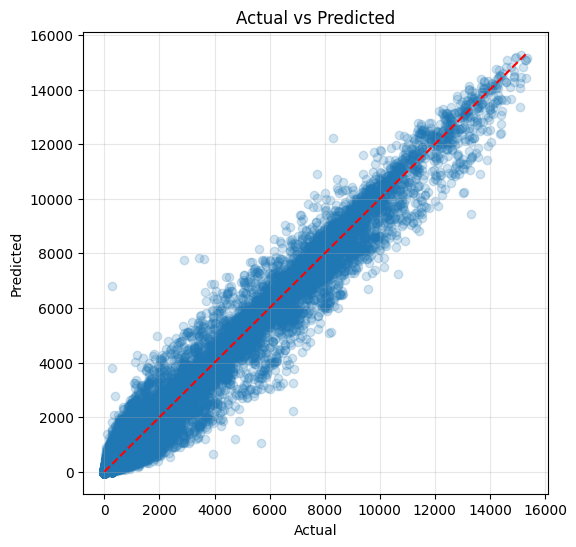

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, lr_preds, alpha=0.2)

# 대각선 추가 (완벽한 예측 기준선)
plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

시간 흐름 그래프

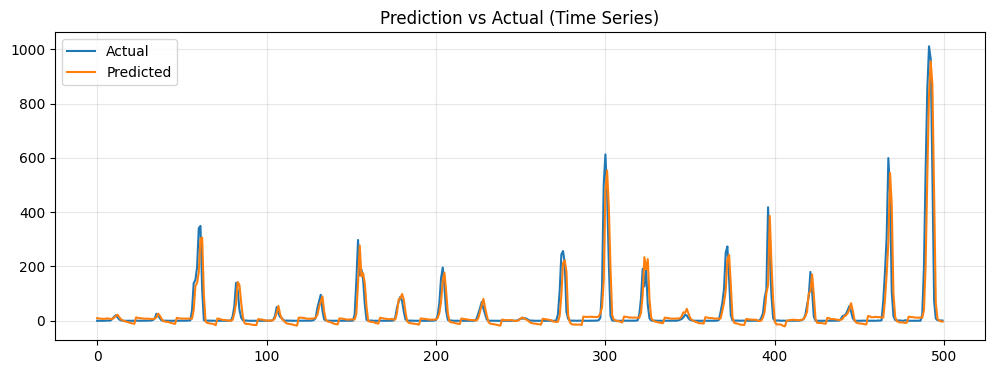

In [20]:
plt.figure(figsize=(12,4))
plt.plot(y_valid.values[:500], label="Actual")
plt.plot(lr_preds[:500], label="Predicted")

plt.legend()
plt.title("Prediction vs Actual (Time Series)")
plt.grid(alpha=0.3)
plt.show()

feature 중요도

In [22]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": lr_model.coef_
})

# 절댓값 기준 정렬 (중요!)
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Top 10 Important Features")
display(coef_df.head(10))

print("Least Important Features")
display(coef_df.tail(10))

Top 10 Important Features


,feature,coef,abs_coef
16,rain,-5.167948,5.167948
14,temperature,-3.379267,3.379267
15,dewpoint,3.192290,3.192290
17,snowfall,2.728948,2.728948
7,month,-2.335652,2.335652
4,is_consumption,1.179224,1.179224
6,weekday,-1.105607,1.105607
5,hour,-1.006414,1.006414
25,lag_1,0.883608,0.883608
20,windspeed_10m,0.734336,0.734336


Least Important Features


,feature,coef,abs_coef
22,euros_per_mwh,0.026695,0.026695
24,highest_price_per_mwh,-0.025626,0.025626
3,product_type,-0.024791,0.024791
18,surface_pressure,0.022494,0.022494
23,lowest_price_per_mwh,0.015413,0.015413
12,eic_count,-0.007999,0.007999
1,county,-0.007143,0.007143
11,data_block_id,-0.003705,0.003705
13,installed_capacity,0.001094,0.001094
0,prediction_unit_id,-0.000120,0.000120
